# Pole + Bell Detection Debug Notebook

This notebook is for tuning the vision pipeline step by step.

Workflow:
1. Load one saved frame.
2. Inspect the image.
3. Try HSV thresholding for the pole.
4. Clean the mask.
5. Keep the most pole-like component.
6. Fit a centerline.
7. Detect the bell circle.
8. Compute bell alignment relative to the pole line.


In [394]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Change this to your saved frame path

IMG_PATH = "../data/extracted_frames/may15/test1_trim/frame_001635.jpg"

def show(img, title="", cmap=None, size=(8, 6)):
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        # OpenCV uses BGR, matplotlib expects RGB
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


## 1. Load and display the original image

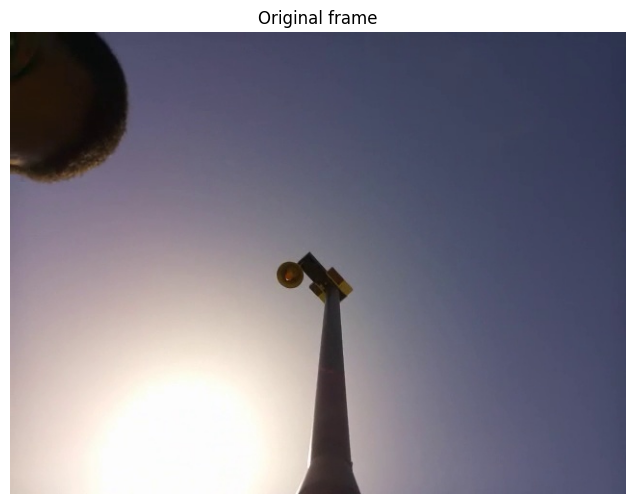

(480, 640, 3)


In [395]:
frame = cv2.imread(IMG_PATH)

if frame is None:
    raise FileNotFoundError(f"Could not read image: {IMG_PATH}")

show(frame, "Original frame")
print(frame.shape)

## 2. Convert to HSV and inspect channels

HSV is useful because:
- `H` = hue / color
- `S` = saturation
- `V` = brightness

Your black pole appears brighter in the camera image, so thresholding only very-low `V` can fail.


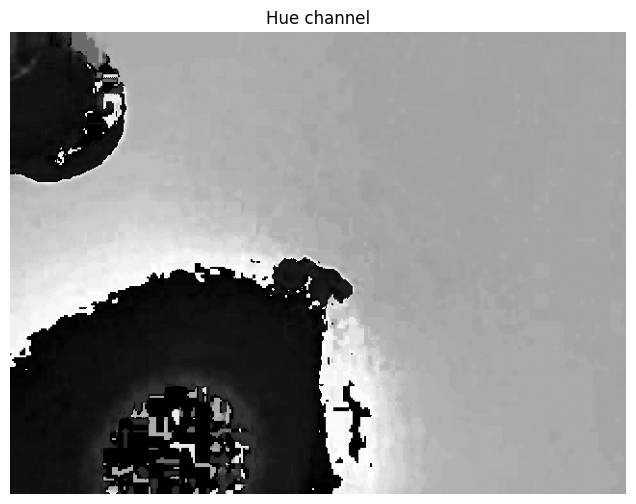

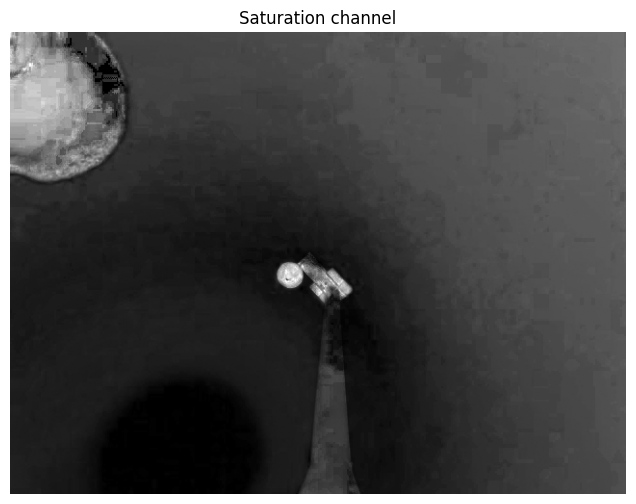

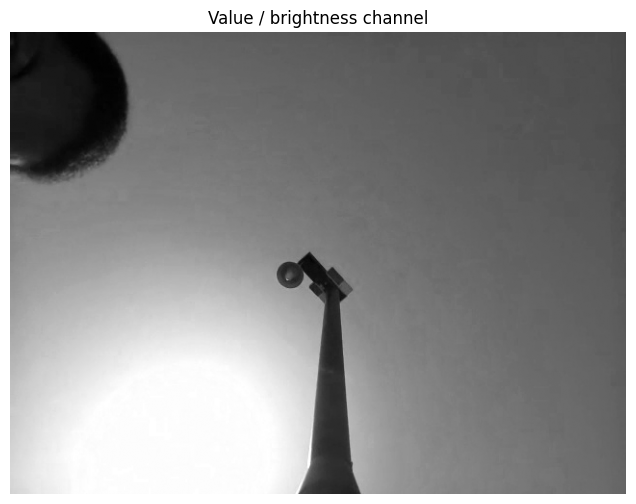

H range: 0 179
S range: 0 255
V range: 8 255


In [396]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

show(h, "Hue channel")
show(s, "Saturation channel")
show(v, "Value / brightness channel")

print("H range:", h.min(), h.max())
print("S range:", s.min(), s.max())
print("V range:", v.min(), v.max())


bell has low hue, high saturation, low-mid brightness

pole has high hue, low saturation, low brightness

## 3. Initial pole mask

For the uploaded image, the pole is not pure black in the frame. It appears gray/greenish due to exposure and lighting.

Tune these values first:
- lower HSV
- upper HSV
- ROI start


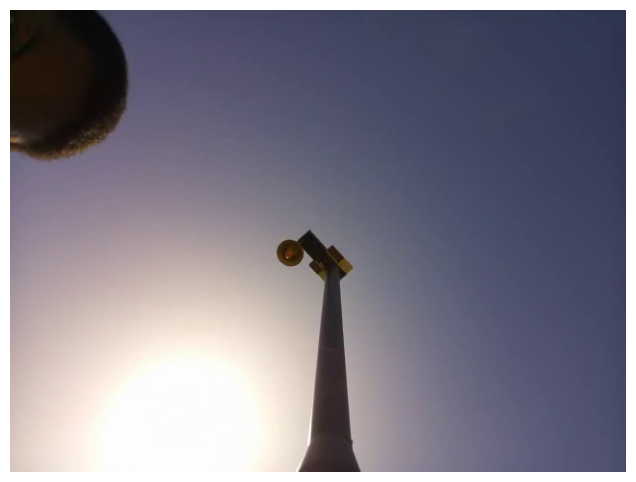

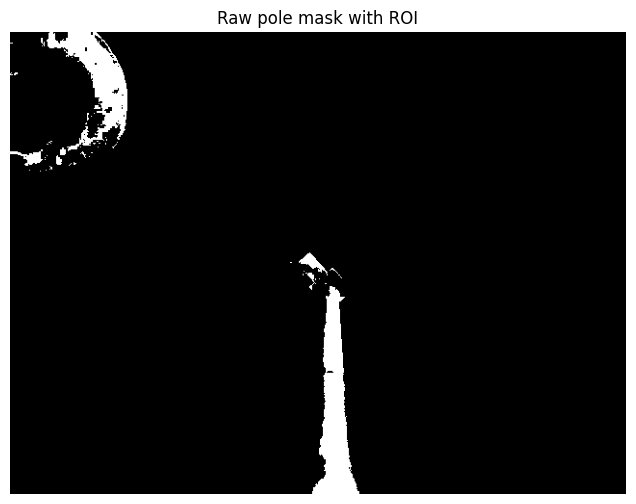

In [413]:
# Tune these
# indoor setup
# LOWER = np.array([50, 25, 50])
# UPPER = np.array([75, 80, 100])

# outdoor setup (sunlight)
# bright regions (hit by sunlight)
LOWER_BRIGHT = np.array([0, 0, 200])
UPPER_BRIGHT = np.array([180, 50, 255])
# dark regions
LOWER_DARK = np.array([0, 0, 0])
UPPER_DARK = np.array([180, 100, 60])

# pole_mask = cv2.inRange(hsv, LOWER, UPPER)
pole_mask_dark = cv2.inRange(hsv, LOWER_DARK, UPPER_DARK)
pole_mask_bright = cv2.inRange(hsv, LOWER_BRIGHT, UPPER_BRIGHT)

near_dark = cv2.dilate(
    pole_mask_dark,
    np.ones((50, 50), np.uint8),
    iterations=1
)

bright_near_dark = cv2.bitwise_and(pole_mask_bright, near_dark)
pole_mask = cv2.bitwise_or(pole_mask_dark, bright_near_dark)
# pole_mask = cv2.bitwise_or(pole_mask_dark, pole_mask_bright)

# Ignore upper part of image where ceiling dominates
roi_start = 0.50   # try 0.45, 0.50, 0.55 depending on camera view
height, width = pole_mask.shape

roi = np.zeros_like(pole_mask)
roi[int(height * roi_start):, :] = 255

# pole_mask = cv2.bitwise_and(pole_mask, roi)

show(frame)
show(pole_mask_dark, "Raw pole mask with ROI")


## 4. Clean the mask

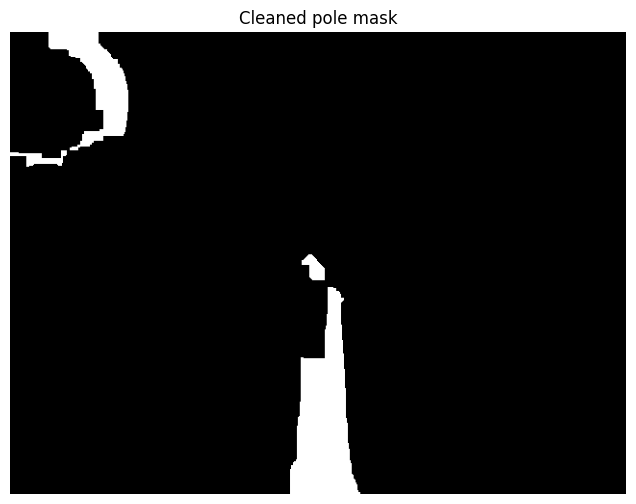

In [414]:
kernel_open = np.ones((3, 3), np.uint8)
kernel_close = np.ones((20, 20), np.uint8)

clean_mask = cv2.morphologyEx(pole_mask, cv2.MORPH_OPEN, kernel_open)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel_close)

show(clean_mask, "Cleaned pole mask")


## 5. Keep only the most pole-like component

This rejects small background regions and circular objects like the bell.


label: 1
aspect: 1.4819277108433735
area: 4194
label: 2
aspect: 3.4705882352941178
area: 433
1502.764705882353
label: 3
aspect: 1.125
area: 388
label: 4
aspect: 2.9452054794520546
area: 8751
25773.493150684928
4


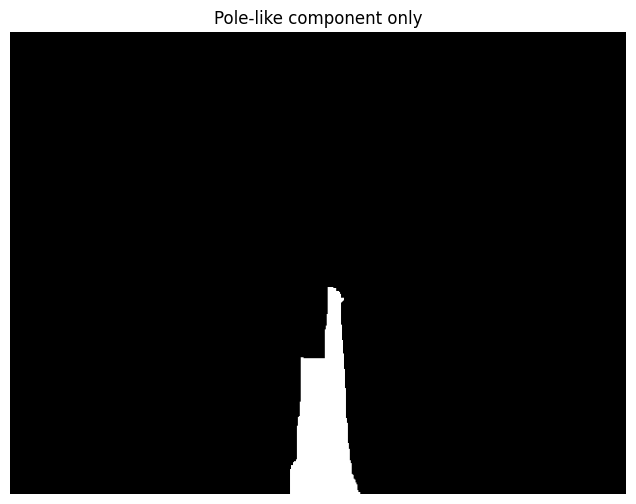

In [415]:
def keep_pole_like_component(mask, min_area=300, min_aspect=1.5):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    best_label = None
    best_score = 0

    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]

        if area < min_area:
            continue

        aspect = max(w, h) / max(1, min(w, h))
        # print(f"h: {h}, w: {w}")
        print(f"label: {label}\naspect: {aspect}\narea: {area}")
        

        if aspect < min_aspect:
            continue

        score = area * aspect
        # score = aspect
        print(score)

        if score > best_score:
            best_score = score
            best_label = label

    if best_label is None:
        return np.zeros_like(mask)
    print(best_label)

    return np.uint8(labels == best_label) * 255


pole_only = keep_pole_like_component(clean_mask)

show(pole_only, "Pole-like component only")


## 6. Fit pole centerline

This fits a line to the selected pole component.


line: (0.05501312389969826, -0.9984856247901917, 325.9842224121094, 399.7904357910156)


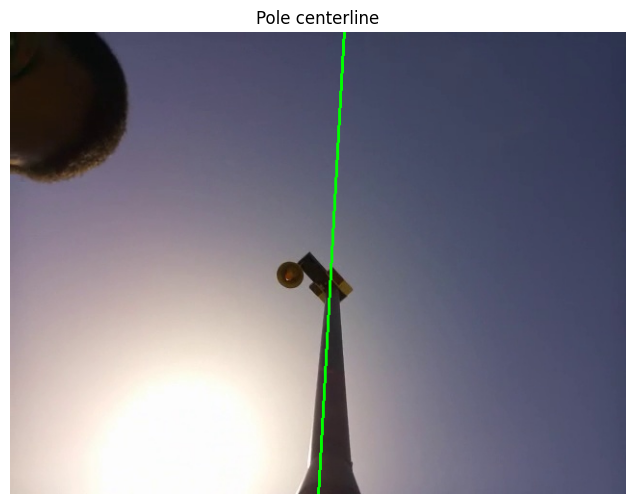

In [412]:
def fit_line_from_mask(mask, min_points=100):
    ys, xs = np.where(mask > 0)

    if len(xs) < min_points:
        return None

    points = np.column_stack((xs, ys)).astype(np.float32)

    vx, vy, x0, y0 = cv2.fitLine(
        points,
        cv2.DIST_L2,
        0,
        0.01,
        0.01
    )

    return float(vx[0]), float(vy[0]), float(x0[0]), float(y0[0])


def draw_line(img, line, color=(0, 255, 0), thickness=2):
    out = img.copy()

    vx, vy, x0, y0 = line
    t = 1000

    x1 = int(x0 - vx * t)
    y1 = int(y0 - vy * t)
    x2 = int(x0 + vx * t)
    y2 = int(y0 + vy * t)

    cv2.line(out, (x1, y1), (x2, y2), color, thickness)
    return out


line = fit_line_from_mask(pole_only)

vis = frame.copy()

if line is not None:
    vis = draw_line(vis, line)
    print("line:", line)
else:
    print("No line detected")

show(vis, "Pole centerline")


## 7. Bell detection with HoughCircles

This is a simple starting point. Tune `param2`, `minRadius`, and `maxRadius`.


[[[226.5 216.5  13.2]]]
[[226 216  13]]
[[226 216  13]]
bell: (np.int64(226), np.int64(216), np.int64(13))


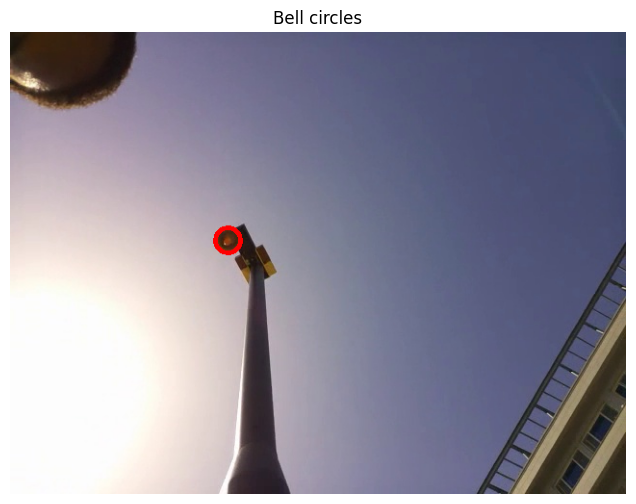

In [391]:
def detect_bell(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.medianBlur(gray, 5)

    circles = cv2.HoughCircles(
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=60,
        param1=300,
        param2=20,
        minRadius=10,
        maxRadius=20
    )
    
    # circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1, minDist=20, param1=150, param2=20, minRadius=0, maxRadius=30)

    if circles is None:
        return None, []
    print(circles)
    circles = np.round(circles[0]).astype(int)
    print(circles)

    # Pick largest circle for now
    best = max(circles, key=lambda c: c[2])
    return tuple(best), circles


bell, circles = detect_bell(frame)
print(circles)

vis = frame.copy()

for x, y, r in circles:
    cv2.circle(vis, (x, y), r, (255, 0, 0), 1)

if bell is not None:
    bx, by, br = bell
    cv2.circle(vis, (bx, by), br, (0, 0, 255), 3)
    # cv2.circle(vis, (bx, by), 3, (0, 0, 255), -1)
    print("bell:", bell)
else:
    print("No bell detected")

show(vis, "Bell circles")


In [392]:
# def orient_line_toward_bell(line, mask, bell_center):
#     vx, vy, x0, y0 = line
#     bx, by = bell_center

#     ys, xs = np.where(mask > 0)
#     pts = np.column_stack((xs, ys)).astype(np.float32)

#     # projection of mask points onto fitted line direction
#     proj = (pts[:, 0] - x0) * vx + (pts[:, 1] - y0) * vy

#     p1 = pts[np.argmin(proj)]
#     p2 = pts[np.argmax(proj)]

#     # endpoint closer to bell is probably the top/bell side of the pole
#     d1 = np.linalg.norm(p1 - np.array([bx, by]))
#     d2 = np.linalg.norm(p2 - np.array([bx, by]))

#     if d1 < d2:
#         top = p1
#         base = p2
#     else:
#         top = p2
#         base = p1

#     new_v = top - base
#     new_v = new_v / (np.linalg.norm(new_v) + 1e-6)

#     new_x0, new_y0 = base

#     return float(new_v[0]), float(new_v[1]), float(new_x0), float(new_y0)

def orient_line_toward_bell(line, mask, bell_center):
    vx, vy, x0, y0 = line
    bx, by = bell_center

    ys, xs = np.where(mask > 0)
    pts = np.column_stack((xs, ys)).astype(np.float32)

    # Projection of mask points onto the fitted line
    proj = (pts[:, 0] - x0) * vx + (pts[:, 1] - y0) * vy

    t_min = np.min(proj)
    t_max = np.max(proj)

    # These endpoints are ON the fitted centerline
    p_min = np.array([x0 + t_min * vx, y0 + t_min * vy])
    p_max = np.array([x0 + t_max * vx, y0 + t_max * vy])

    bell = np.array([bx, by])

    # The endpoint closer to the bell should be the "top" direction
    d_min = np.linalg.norm(p_min - bell)
    d_max = np.linalg.norm(p_max - bell)

    if d_max < d_min:
        # current direction points toward bell
        return vx, vy, x0, y0
    else:
        # flip direction, but keep same point on line
        return -vx, -vy, x0, y0

## 8. Compute alignment error

The error is the signed distance of the bell center from the pole centerline.

You need to manually check which sign means left/right for your robot.


(0.012906983494758606, 0.999916672706604, 248.34231567382812, 392.67218017578125)
LEFT SIDE, error=-20.1


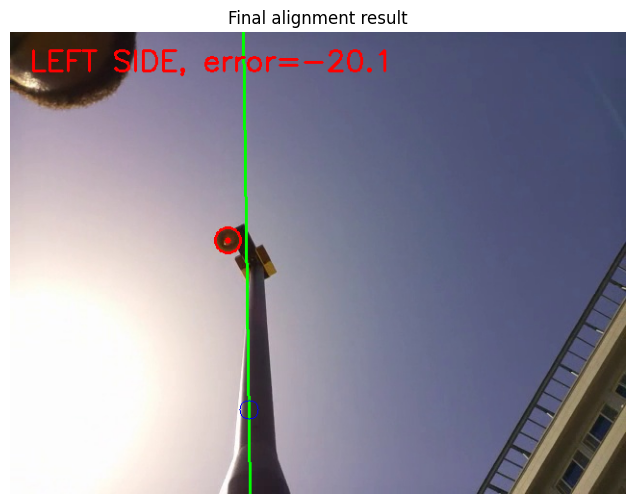

In [393]:
def signed_distance_to_line(px, py, line):
    vx, vy, x0, y0 = line
    return vx * (py - y0) - vy * (px - x0)


ALIGN_THRESH_PX = 20

vis = frame.copy()

if line is not None:
    vis = draw_line(vis, line)

if bell is not None:
    bx, by, br = bell
    cv2.circle(vis, (bx, by), br, (0, 0, 255), 2)
    cv2.circle(vis, (bx, by), 3, (0, 0, 255), -1)

if line is not None and bell is not None:
    bx, by, _ = bell
    print(line)

    oriented_line = orient_line_toward_bell(
        line,
        pole_only,
        bell_center=(bx, by)
    )

    error = signed_distance_to_line(bx, by, oriented_line)

    if abs(error) < ALIGN_THRESH_PX:
        status = f"ALIGNED, error={error:.1f}"
    elif error > 0:
        status = f"RIGHT SIDE, error={error:.1f}"
    else:
        status = f"LEFT SIDE, error={error:.1f}"

    print(status)
    vx, vy, x0, y0 = oriented_line
    cv2.circle(vis, (int(x0),int(y0)), 10, (255,0,0))
    cv2.putText(vis, status, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)
else:
    print("Need both pole line and bell detection")

show(vis, "Final alignment result")


## 9. Optional: test on webcam / Pi camera

Use this only after the image pipeline works on saved frames.

On Raspberry Pi, if your camera frame is RGB instead of BGR, change:

```python
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
```

to:

```python
hsv = cv2.cvtColor(frame, cv2.COLOR_RGB2HSV)
```
